# Context Engineering — Prompts, Parámetros y Tokenización

_De prompt engineering al arte de diseñar **todo** lo que ve el modelo: contexto, ejemplos, herramientas, memoria_

**Módulo 3 — Introducción a AI Engineering** | DSRP Machine Learning Engineering
**Profesor:** Miguel Arquez

![AI Engineering](assets/header.png)

## 1. De Prompt Engineering a Context Engineering

**Prompt engineering** es la práctica de escribir buenas instrucciones para un LLM: ajustar palabras, ejemplos, formato hasta obtener la respuesta deseada.

**Context engineering** — popularizado por Andrej Karpathy y Anthropic durante 2024-2025 — es el siguiente nivel y se ha vuelto el frame dominante para construir con LLMs serios:

> _Context engineering es el arte y la ciencia de **rellenar la ventana de contexto** con la información correcta para el siguiente paso del modelo._
> — Andrej Karpathy (2024)

La diferencia es de **alcance**:

| | Prompt Engineering | Context Engineering |
|---|---|---|
| Foco | el string de instrucciones | **todo** lo que ve el modelo en una pasada |
| Naturaleza | estático, redactado a mano | dinámico, ensamblado programáticamente |
| Incluye | system + user prompt | system, user, history, RAG, tools, memoria, output schema |
| Métrica | "¿el prompt funciona?" | "¿el contexto es relevante, denso y dentro del presupuesto?" |
| Skill clave | escribir bien | **seleccionar, comprimir y orquestar** información |

Un asistente moderno (Claude Code, ChatGPT con tools, un agente RAG) no usa un solo prompt — **construye el contexto en cada turno**: recupera documentos relevantes, resume historial viejo, inyecta resultados de herramientas, define schemas de salida. El prompt sigue siendo necesario, pero es **una pieza** del context engineering.

Este notebook cubre ambos niveles: el "qué escribir" (prompt engineering, técnicas, parámetros) y el "qué ensamblar" (context engineering: stack, presupuestos, compactación, RAG, memoria).

## 2. El "context stack" — qué hay dentro de la ventana de contexto

En una llamada moderna a un LLM, el contexto se ensambla a partir de **varias capas**, todas concatenadas y enviadas al modelo en cada turno:

```
┌────────────────────────────────────────────────────────┐
│  SYSTEM PROMPT      reglas, rol, formato, restricciones │
├────────────────────────────────────────────────────────┤
│  TOOL DEFINITIONS   firmas y descripciones de funciones │
├────────────────────────────────────────────────────────┤
│  FEW-SHOT EXAMPLES  pares input → output de referencia  │
├────────────────────────────────────────────────────────┤
│  RETRIEVED DOCS     pasajes traídos por RAG             │
├────────────────────────────────────────────────────────┤
│  MEMORY / STATE     hechos del usuario, preferencias    │
├────────────────────────────────────────────────────────┤
│  CONVERSATION       turnos previos (user/assistant)     │
├────────────────────────────────────────────────────────┤
│  TOOL RESULTS       outputs de funciones ya ejecutadas  │
├────────────────────────────────────────────────────────┤
│  USER MESSAGE       lo que el usuario acaba de decir    │
└────────────────────────────────────────────────────────┘
                       ↓
                 ventana de contexto
                 (tokens limitados por el modelo)
```

**Tu trabajo como context engineer**: decidir, en cada turno, **qué cabe**, en **qué orden**, con **qué nivel de detalle**, dentro del **presupuesto de tokens** que tiene el modelo.

No todas las capas son obligatorias. Una llamada simple usa solo system + user. Un agente serio puede tener las 8 capas activas, ensambladas dinámicamente por el código de tu app.

In [1]:
# El context stack en práctica — esto es lo que realmente llega al modelo
mensajes = [
    # ───────── SYSTEM ─────────
    {'role': 'system', 'content':
        'Eres un asistente de soporte de DSRP. Responde en español. '
        'Cita la fuente con [DOC#] cuando uses información recuperada.'},

    # ───── RETRIEVED DOCS (RAG, inyectados como system o user) ─────
    {'role': 'system', 'content':
        '<retrieved>\n'
        '[DOC1] Para resetear el password: Configuración > Cuenta > "Olvidé mi contraseña".\n'
        '[DOC2] Las sesiones expiran a las 24h por seguridad.\n'
        '</retrieved>'},

    # ───── FEW-SHOT EXAMPLES ─────
    {'role': 'user',      'content': '¿Cómo reseteo mi password?'},
    {'role': 'assistant', 'content': 'Ve a Configuración → Cuenta → "Olvidé mi contraseña" [DOC1].'},

    # ───── CONVERSATION HISTORY ─────
    {'role': 'user',      'content': 'Hola, me echó de la app sin avisar.'},
    {'role': 'assistant', 'content': 'Hola, tu sesión expira a las 24h [DOC2]. Inicia sesión de nuevo.'},

    # ───── USER MESSAGE (lo nuevo) ─────
    {'role': 'user', 'content': 'Y si ya no me acuerdo la contraseña, ¿qué hago?'},
]

print('Context stack ensamblado:\n')
for m in mensajes:
    preview = m['content'].replace('\n', ' ')[:80]
    print(f'  [{m["role"].upper():9}] {preview}{"…" if len(m["content"]) > 80 else ""}')

Context stack ensamblado:

  [SYSTEM   ] Eres un asistente de soporte de DSRP. Responde en español. Cita la fuente con [D…
  [SYSTEM   ] <retrieved> [DOC1] Para resetear el password: Configuración > Cuenta > "Olvidé m…
  [USER     ] ¿Cómo reseteo mi password?
  [ASSISTANT] Ve a Configuración → Cuenta → "Olvidé mi contraseña" [DOC1].
  [USER     ] Hola, me echó de la app sin avisar.
  [ASSISTANT] Hola, tu sesión expira a las 24h [DOC2]. Inicia sesión de nuevo.
  [USER     ] Y si ya no me acuerdo la contraseña, ¿qué hago?


## 3. Roles: system, user, assistant

En la API de chat completions hay tres roles. Son las **capas más básicas** del context stack:

| Rol | Qué pone | Cuándo se usa |
|---|---|---|
| **system** | instrucciones generales, personalidad, restricciones, formato de salida, docs recuperados | una o varias veces, fijo entre turnos |
| **user** | el mensaje del humano | en cada turno |
| **assistant** | las respuestas previas del modelo | se acumulan en multi-turno |

> 💡 **El system prompt es el mensaje más poderoso**: define el "modo de juego" para toda la conversación. Inviertelo bien.

```python
messages = [
    {'role': 'system', 'content':
        'Eres un revisor de código senior. Devuelves bullets concisos. '
        'Si el código está bien, dilo en una frase. No inventes problemas.'},
    {'role': 'user', 'content': 'Revisa este snippet:\n```python\n...\n```'},
]
```

Algunos proveedores (Anthropic, OpenAI Responses API) además aceptan **`developer`** o roles personalizados — son matices, la idea es la misma.

## 4. Técnicas de prompting

Todas estas técnicas son **formas de poblar la capa "instructions / few-shot"** del context stack.

### 4.1 Zero-shot
Le pides al modelo que haga una tarea sin ejemplos. Es el default.

```
Clasifica este review como POSITIVO o NEGATIVO:
"El producto llegó roto y nadie respondió mis emails."
```

### 4.2 Few-shot (in-context learning)
Le das **ejemplos resueltos** dentro del prompt. Aprende el patrón sin reentrenar.

```
Review: "Llegó tarde pero funciona."  → MIXTO
Review: "Increíble, lo recomiendo."     → POSITIVO
Review: "Una porquería."                → NEGATIVO
Review: "Ni fu ni fa."                  →
```

### 4.3 Chain-of-Thought (CoT)
Le pides al modelo que **razone paso a paso** antes de responder. Mejora dramáticamente en tareas de razonamiento, matemáticas y lógica multi-paso.

```
Resuelve y muestra tu razonamiento paso a paso:
"Si una máquina produce 60 piezas en 12 minutos, ¿cuántas en 1 hora?"
```

### 4.4 Role prompting
"Eres un X experto en Y" — encuadra al modelo en un dominio.

### 4.5 Structured output
Pídele JSON con un schema concreto y, si el proveedor lo soporta, usa `response_format={'type': 'json_object'}` o JSON Schema. Evita parsear texto libre.

### 4.6 ReAct (Reason + Act)
El modelo alterna **pensamiento** y **acciones** (llamadas a tools/funciones). Base de los agentes.

### 4.7 Self-consistency
Genera $N$ respuestas (con `temperature > 0`), toma la **respuesta más frecuente**. Sube la precisión en tareas de razonamiento.

## 5. Optimización de prompts

Pautas que funcionan en cualquier modelo moderno:

1. **Sé específico** — "Resume en 3 bullets de máximo 15 palabras cada uno" > "Resume corto".
2. **Da contexto y rol** — qué es la app, quién es el usuario, qué tono se espera.
3. **Usa delimitadores** para separar partes:
   - Triple backtick para bloques de código.
   - `### Instrucciones`, `### Datos`, `### Salida esperada`.
   - Tags XML (`<context>`, `<question>`) — particularmente recomendados por Anthropic.
4. **Pon las instrucciones críticas al principio Y al final** — el modelo presta más atención a esos extremos (ver "lost in the middle" en la sección 6.4).
5. **Da ejemplos** (few-shot) si la tarea es ambigua o el formato es estricto.
6. **Especifica el formato de salida**: JSON con tales campos, markdown con tales secciones, etc.
7. **Negative prompting** — "NO inventes hechos. Si no sabes, di 'no lo sé'".
8. **Iterar** — empieza con un prompt corto, mide errores, agrega ejemplos para los casos que fallan.

## 6. Gestión del context window — el contexto NO es gratis

Las ventanas de contexto modernas son enormes (Gemini 2.5: 2M tokens; Claude 4.x: 200K-1M; GPT-4o: 128K), pero **llenarlas al máximo no es buena idea**:

- **Cuesta dinero** — los input tokens se cobran (más baratos que los output, pero a millones se nota).
- **Cuesta latencia** — el _prefill_ procesa todo el contexto antes de generar el primer token de output.
- **Cuesta calidad** — más contexto ≠ mejor respuesta. Los modelos sufren de **"lost in the middle"**: prestan más atención al inicio y al final.
- **Crece la superficie de errores** — más distractores → más alucinaciones.

### 6.1 Context budgeting

Trata cada contexto como un **presupuesto de tokens** y reparte entre las capas:

```
Presupuesto total: 8 000 tokens

System prompt + tools     :   500 tok  (fijo)
Few-shot examples         :   800 tok
Retrieved docs (top-k)    : 3 000 tok
Conversation history      : 2 000 tok
User message              :   200 tok
─────────────────────────────────────
Subtotal input            : 6 500 tok
Reservado para output     : 1 500 tok
─────────────────────────────────────
Total                     : 8 000 tok
```

Cuando una capa se sale de su presupuesto, **se recorta** (no se ignora el resto del stack).

### 6.2 Compactación de historial

Cuando el historial conversacional crece, no lo borres — **resúmelo**:

```
turns 1-20  →  [resumen: el usuario quería X, le respondimos Y, …]
turn 21     →  literal
turn 22     →  literal
turn 23     →  literal
```

Es la técnica que usan ChatGPT, Claude Code, Cursor y demás agentes para conversaciones largas. Disparo típico: cuando el contexto cruza un umbral (p. ej. 70% de la ventana).

### 6.3 Recuperación selectiva (RAG)

En lugar de mandar **un documento entero**, mandas solo los **fragmentos relevantes** a la pregunta actual. Es la base de **RAG (Retrieval-Augmented Generation)**:

1. **Indexar** los documentos → vectores con un modelo de embeddings → vector DB (Chroma, Pinecone, pgvector).
2. **Recuperar** los top-k fragmentos más cercanos a la query del usuario.
3. **Inyectar** los fragmentos en el contexto como "retrieved docs".
4. **Generar** la respuesta condicionada a esos fragmentos.

RAG es _context engineering_ aplicado a documentos: seleccionas qué porción del corpus es relevante para esta query. Lo profundizamos en notebooks futuros del programa.

### 6.4 Lost in the middle — el orden importa

Los modelos prestan más atención al **inicio** y al **final** del contexto que a la mitad (Liu et al., 2023). Implicaciones prácticas:

- **Pon las instrucciones críticas al inicio Y repítelas al final** del system prompt.
- En RAG: ordena los chunks recuperados con el **más relevante al final** — más cerca del user message.
- Si el contexto es muy largo y la información clave queda en medio, considera comprimir o reorganizar.

> Liu et al. (2023): la precisión cae **20-30%** cuando el dato relevante está en el centro de un contexto largo vs en los extremos.

### 6.5 Context rot

A medida que el contexto crece, la calidad **degrada gradualmente** incluso si toda la info importante está presente:
- Más distractores → modelo se desconcentra.
- Más conflictos potenciales entre fragmentos.
- Peor seguimiento de instrucciones (las "olvida" o las contradice).

Síntoma típico: un prompt que funciona perfecto con 2 K tokens de contexto empieza a alucinar a 50 K. **La solución no es más contexto, es mejor contexto** — comprime, filtra, prioriza.

### 6.6 Memoria persistente

Para que un asistente "te conozca" entre sesiones, hay que mantener **memoria** fuera de la ventana y reinyectar las partes relevantes:

- **Hechos del usuario** ("trabaja con TypeScript", "prefiere respuestas en español").
- **Preferencias** ("evita `var`", "incluye tests").
- **Decisiones de proyecto** ("usamos `pnpm`, no `npm`").

La memoria es solo otra capa del context stack, pero gestionada con almacenamiento propio (DB, archivos, MCP server) y reglas explícitas de cuándo recordar / olvidar.

In [2]:
# Context budgeting práctico — repartir tokens por capa con tiktoken
import tiktoken
enc = tiktoken.encoding_for_model('gpt-4o-mini')

PRESUPUESTO_TOTAL = 8_000
RESERVA_OUTPUT    = 1_500

capas = {
    'system':    'Eres un asistente conciso. Respondes en español…' * 5,
    'tools':     'Function get_weather(city)…' * 8,
    'few_shot':  'Ejemplo 1: …\nEjemplo 2: …' * 10,
    'retrieved': '[DOC1] …\n[DOC2] …\n[DOC3] …\n' * 40,
    'history':   'user: …\nassistant: …\n' * 30,
    'user':      '¿Cómo configuro el SSO en mi cuenta?',
}

usado = {k: len(enc.encode(v)) for k, v in capas.items()}
total_input       = sum(usado.values())
disponible_output = PRESUPUESTO_TOTAL - total_input

print(f'{"capa":<12} {"tokens":>7}   {"% del total":>12}')
print('-' * 35)
for k, v in usado.items():
    pct = v / PRESUPUESTO_TOTAL * 100
    print(f'{k:<12} {v:>7}   {pct:>10.1f} %')

print('-' * 35)
print(f'{"input":<12} {total_input:>7}')
print(f'{"output libre":<12} {disponible_output:>7}')
print(f'{"presupuesto":<12} {PRESUPUESTO_TOTAL:>7}')

if disponible_output < RESERVA_OUTPUT:
    print(f'\n⚠️  Solo quedan {disponible_output} tokens para output (objetivo: {RESERVA_OUTPUT}).')
    print('   Recorta una capa: comprime history, baja top-k de retrieval o quita few-shot.')
else:
    print(f'\n✅ Cabe con {disponible_output - RESERVA_OUTPUT} tokens de margen.')

capa          tokens    % del total
-----------------------------------
system            70          0.9 %
tools             40          0.5 %
few_shot         120          1.5 %
retrieved        600          7.5 %
history          180          2.2 %
user              10          0.1 %
-----------------------------------
input           1020
output libre    6980
presupuesto     8000

✅ Cabe con 5480 tokens de margen.


## 7. Modelos de razonamiento (reasoning models)

Una familia que **piensa antes de responder**: gastan tokens internos ("thinking tokens") explorando varias rutas y luego entregan la respuesta final.

| Modelo | Proveedor |
|---|---|
| o1, o3, o3-mini | OpenAI |
| Claude Opus / Sonnet / Haiku 4.x con _extended thinking_ | Anthropic |
| Gemini 2.5 Pro con _thinking_ | Google |
| DeepSeek R1, QwQ | open-source |

**Trade-offs:**
- ✅ Mucho mejores en matemáticas, lógica, planning, código difícil.
- ❌ Más caros (los thinking tokens también se cobran) y más lentos.
- ❌ Para tareas simples (resumir, clasificar) son overkill.

**Implicación para context engineering:** los reasoning models gastan **parte del presupuesto de output en pensar**. Si controlas un parámetro como `reasoning_effort` (OpenAI) o `thinking.budget_tokens` (Anthropic), inclúyelo en tu cálculo de presupuesto. El CoT explícito en el prompt es menos necesario — el modelo ya razona internamente.

## 8. Parámetros de generación

Aunque el contexto y el prompt son lo más importante, los **parámetros** del decoding ajustan cómo el modelo elige cada token. Esta es la lista práctica:

| Parámetro | Rango típico | Qué controla |
|---|---|---|
| `temperature` | 0.0 – 2.0 | Aleatoriedad. 0 = determinista, alto = creativo/caótico |
| `top_p` (nucleus) | 0.0 – 1.0 | Muestrea solo entre los tokens cuya probabilidad acumulada llega a `p` |
| `top_k` | 1 – 100+ | Considera solo los `k` tokens más probables (no en OpenAI; sí en HF, Gemini, Ollama) |
| `max_tokens` (o `max_completion_tokens`) | int | Largo máximo de la respuesta |
| `frequency_penalty` | -2.0 – 2.0 | Castiga tokens que ya aparecieron mucho (reduce repetición literal) |
| `presence_penalty` | -2.0 – 2.0 | Castiga tokens que ya aparecieron al menos una vez (fomenta variedad temática) |
| `stop` | string o lista | Secuencias que cortan la generación al aparecer |
| `seed` | int | Semilla para resultados (mayormente) reproducibles |
| `n` | int | Cuántas respuestas independientes generar |
| `response_format` | dict | `{'type': 'json_object'}` o JSON Schema para forzar estructura |
| `tools` / `tool_choice` | lista | Function calling — el modelo puede pedir ejecutar funciones |
| `logprobs`, `top_logprobs` | bool / int | Devuelve probabilidades de los tokens (útil para evals) |
| `stream` | bool | Devuelve la respuesta token a token |

> ⚠️ **Regla de oro**: ajusta `temperature` **o** `top_p`, no los dos a la vez.

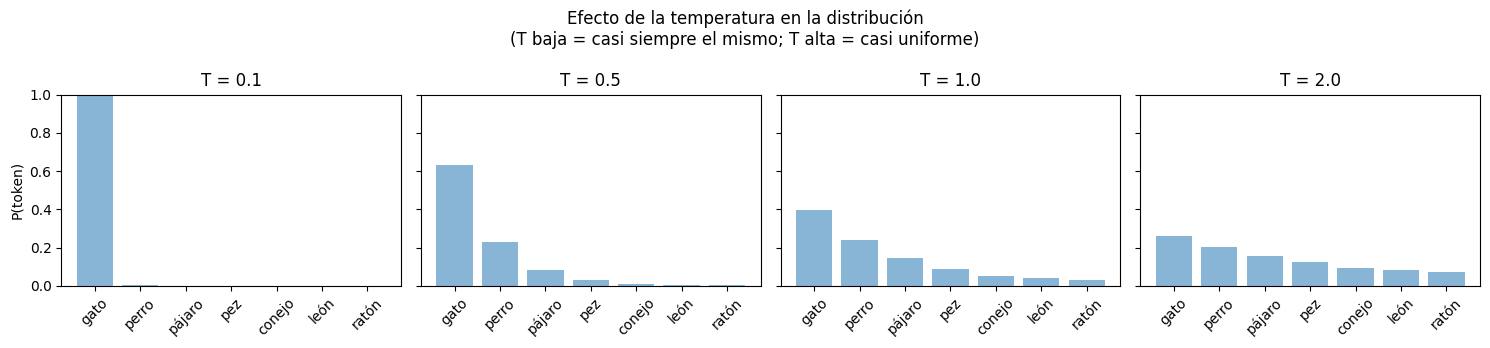

In [3]:
# Visualizar cómo temperature reescala una distribución de probabilidades
import numpy as np
import matplotlib.pyplot as plt

logits = np.array([2.5, 2.0, 1.5, 1.0, 0.5, 0.2, 0.0])
tokens = ['gato', 'perro', 'pájaro', 'pez', 'conejo', 'león', 'ratón']

def softmax(x, T):
    e = np.exp(x / T)
    return e / e.sum()

fig, axes = plt.subplots(1, 4, figsize=(15, 3.5), sharey=True)
for ax, T in zip(axes, [0.1, 0.5, 1.0, 2.0]):
    p = softmax(logits, T)
    ax.bar(tokens, p, color='#88B5D6')
    ax.set_title(f'T = {T}')
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=45)
axes[0].set_ylabel('P(token)')
fig.suptitle('Efecto de la temperatura en la distribución\n(T baja = casi siempre el mismo; T alta = casi uniforme)')
plt.tight_layout(); plt.show()

### 8.1 Cuándo usar qué temperature

| Tarea | Temperature recomendada |
|---|---|
| Extracción de información, clasificación, parsing | 0.0 |
| QA factual, traducción técnica | 0.0 – 0.2 |
| Code completion | 0.1 – 0.3 |
| Conversación general | 0.5 – 0.7 |
| Brainstorming, ideación, escritura creativa | 0.8 – 1.2 |

### 8.2 top_p vs top_k vs temperature

- **temperature**: cómo de "plana" hacer la distribución antes de muestrear.
- **top_k**: corta a los `k` tokens más probables (sampling truncado).
- **top_p (nucleus)**: corta al menor conjunto de tokens cuya probabilidad acumulada ≥ `p`. Más adaptativo que top_k.

En la práctica, la receta más común es: `temperature` para creatividad + `top_p ≈ 0.9` para evitar tokens muy improbables. `top_k` lo expone HF / Gemini / Ollama; OpenAI no lo expone.

## 9. Function calling / tool use — herramientas como contexto

El modelo decide cuándo llamar a una **función** que tú definiste y devuelve los argumentos en JSON. Tu código ejecuta la función y le pasa el resultado al modelo. Es la base de los **agentes**.

Desde el punto de vista de context engineering, los **tools son una capa más del context stack**: sus firmas y descripciones se añaden al inicio (consumiendo tokens) y sus resultados se inyectan en el contexto a medida que se ejecutan.

```python
tools = [{
    'type': 'function',
    'function': {
        'name': 'get_weather',
        'description': 'Devuelve el clima actual de una ciudad.',
        'parameters': {
            'type': 'object',
            'properties': {'city': {'type': 'string'}},
            'required': ['city'],
        },
    },
}]

resp = client.chat.completions.create(
    model='gpt-4o-mini',
    messages=[{'role': 'user', 'content': '¿Cómo está el clima en Lima?'}],
    tools=tools,
)
# El modelo NO responde texto; devuelve una "tool_call" pidiendo ejecutar
# get_weather(city='Lima'). Tú la ejecutas, le devuelves el resultado y
# el modelo construye la respuesta final.
```

**Implicación de presupuesto**: cada tool que registras (descripción + schema de parámetros) puede ser 50-200 tokens. Si registras 30 tools, gastaste 3-6 K tokens **antes** de empezar la conversación. Curar la lista de tools relevantes para el turno actual es context engineering puro.

## 10. Tokenización

Los LLMs **no ven caracteres ni palabras**: ven **tokens**, que son fragmentos de texto definidos por un tokenizer aprendido durante el entrenamiento. La unidad de toda nuestra contabilidad (presupuesto, pricing, context window) es el token.

> "machine learning" → `["machine", " learning"]` (2 tokens)
> "modeloLLM" → `["model", "oL", "LM"]` (3 tokens)
> "你好" → `["你", "好"]` (2 tokens; en GPT-4 podría ser 1)

Tres familias dominantes:

| Algoritmo | Cómo funciona | Modelos típicos |
|---|---|---|
| **BPE (Byte-Pair Encoding)** | empieza a nivel de byte y une los pares más frecuentes hasta tener un vocabulario fijo | GPT, LLaMA, Mistral |
| **WordPiece** | similar a BPE pero une por incremento de likelihood, no por frecuencia | BERT |
| **SentencePiece (Unigram / BPE)** | trabaja sobre el texto crudo (no necesita pre-tokenizar) | T5, Llama, mT5 |

**Por qué importa:**
- **Pricing**: cobran por tokens, no caracteres.
- **Context window**: el límite del modelo se mide en tokens (p. ej. 200K tokens ≈ 150K palabras en inglés).
- **Multi-idioma**: idiomas no-latinos suelen consumir más tokens por carácter.
- **Decoding**: el modelo predice un token a la vez.

In [4]:
# tiktoken: tokenizador oficial de OpenAI
# uv add tiktoken
import tiktoken

enc = tiktoken.encoding_for_model('gpt-4o-mini')

textos = [
    'Hello, world!',
    'Hola mundo!',
    '你好，世界！',
    '🚀 supercalifragilisticexpialidocious',
    'def fibonacci(n): return n if n < 2 else fibonacci(n-1) + fibonacci(n-2)',
]

print(f'{"texto":<70} | tokens | n_tokens')
print('-' * 110)
for t in textos:
    ids = enc.encode(t)
    piezas = [enc.decode([i]) for i in ids]
    print(f'{t:<70} | {len(ids):>6} | {piezas}')

texto                                                                  | tokens | n_tokens
--------------------------------------------------------------------------------------------------------------
Hello, world!                                                          |      4 | ['Hello', ',', ' world', '!']
Hola mundo!                                                            |      3 | ['Hola', ' mundo', '!']
你好，世界！                                                                 |      4 | ['你好', '，', '世界', '！']
🚀 supercalifragilisticexpialidocious                                   |     12 | ['�', '�', ' super', 'cal', 'if', 'rag', 'il', 'istic', 'exp', 'ial', 'id', 'ocious']
def fibonacci(n): return n if n < 2 else fibonacci(n-1) + fibonacci(n-2) |     23 | ['def', ' fibonacci', '(n', '):', ' return', ' n', ' if', ' n', ' <', ' ', '2', ' else', ' fibonacci', '(n', '-', '1', ')', ' +', ' fibonacci', '(n', '-', '2', ')']


In [5]:
# Estimar costo antes de enviar
PRECIO_INPUT  = 0.15 / 1_000_000   # gpt-4o-mini, USD por token
PRECIO_OUTPUT = 0.60 / 1_000_000

prompt = '''Eres un asistente que resume papers de Machine Learning en 3 bullets.
Resume el siguiente abstract:

[ABSTRACT MUY LARGO HIPOTÉTICO DE UN PAPER...]
''' * 20   # simulamos un prompt grande

n_input  = len(enc.encode(prompt))
n_output_estimado = 200   # 3 bullets cortos

costo = n_input * PRECIO_INPUT + n_output_estimado * PRECIO_OUTPUT
print(f'Tokens de input estimados : {n_input:,}')
print(f'Tokens de output estimados: {n_output_estimado:,}')
print(f'Costo aproximado por llamada: ${costo:.6f}')
print(f'Costo por 10.000 llamadas  : ${costo*10_000:,.2f}')

Tokens de input estimados : 760
Tokens de output estimados: 200
Costo aproximado por llamada: $0.000234
Costo por 10.000 llamadas  : $2.34


### Visualización interactiva — OpenAI Tokenizer

OpenAI ofrece una herramienta web donde **pegas un texto y ves cómo se tokeniza**, con cada token coloreado:

🔗 **https://platform.openai.com/tokenizer**

Recomendada para:
- Entender por qué tu factura es más alta de lo esperado (tokens "raros" cuestan más).
- Diseñar prompts eficientes (acortar instrucciones repetitivas).
- Comparar idiomas — es ilustrativo ver cuántos tokens más usa el chino o el árabe vs el inglés.

## 11. Cheatsheet de buenas prácticas

**Prompt:**
1. **System prompt corto, claro, con rol y restricciones.**
2. **Few-shot solo si la tarea es ambigua** — los ejemplos consumen tokens.
3. **Pide JSON estructurado** cuando vayas a parsear (`response_format` con JSON Schema).
4. **`temperature=0` para tareas determinísticas**, mayor solo si necesitas creatividad.
5. **`max_tokens` siempre**: te protege de respuestas infinitas.

**Contexto:**
6. **Trata el contexto como un presupuesto**, reparte por capa, recorta cuando se pase.
7. **Comprime historial viejo** en lugar de borrarlo — resumen + últimos N turnos literales.
8. **Ordena RAG por relevancia, con el chunk más relevante al final** (cerca del user message).
9. **Repite instrucciones críticas al inicio Y al final** del system prompt.
10. **Más contexto ≠ mejor**: combate el context rot, manda menos pero mejor.
11. **Curar la lista de tools** — solo registra los que el modelo realmente puede necesitar este turno.

**Engineering:**
12. **Versiona prompts y context-assembly como código** (git, code review, semver).
13. **Cuenta tokens antes de mandar** — `tiktoken` o el SDK del proveedor.
14. **Build evals** — 20-50 casos con respuestas esperadas, corre tras cada cambio.
15. **Loggea cada llamada** — contexto ensamblado, output, latencia, tokens, costo.
16. **Para problemas difíciles, prueba un reasoning model** antes de inflar el prompt.

## 12. Referencias

**Context Engineering**
- Karpathy, A. (2024) — "*context engineering*" — concepto popularizado en X/Twitter: https://x.com/karpathy/status/1937902205765607626
- Anthropic — *Building effective agents*: https://www.anthropic.com/research/building-effective-agents
- Anthropic — *Effective context engineering for AI agents*: https://www.anthropic.com/engineering/effective-context-engineering-for-ai-agents
- LangChain — *Context engineering: the new skill for AI engineers*: https://blog.langchain.com/context-engineering-for-agents/
- Liu, N. et al. (2023) — *Lost in the Middle: How Language Models Use Long Contexts*: https://arxiv.org/abs/2307.03172
- Phil Schmid — *The new skill in AI is not prompting, it's context engineering*: https://www.philschmid.de/context-engineering

**Prompt Engineering**
- OpenAI — *Prompt engineering guide*: https://platform.openai.com/docs/guides/prompt-engineering
- Anthropic — *Prompt engineering overview*: https://docs.anthropic.com/en/docs/build-with-claude/prompt-engineering/overview
- Google — *Gemini prompting strategies*: https://ai.google.dev/gemini-api/docs/prompting-strategies
- Wei, J. et al. (2022) — *Chain-of-Thought Prompting*: https://arxiv.org/abs/2201.11903
- Wang, X. et al. (2022) — *Self-Consistency Improves CoT*: https://arxiv.org/abs/2203.11171
- Yao, S. et al. (2022) — *ReAct*: https://arxiv.org/abs/2210.03629
- *Prompting Guide* (comunidad): https://www.promptingguide.ai/

**Tokenización**
- Sennrich, R. et al. (2015) — *Neural Machine Translation of Rare Words with Subword Units* (BPE): https://arxiv.org/abs/1508.07909
- OpenAI Tokenizer (visualización interactiva): https://platform.openai.com/tokenizer
- tiktoken: https://github.com/openai/tiktoken